In [15]:
import os
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from data_utils import vectorize_text
from model_utils import evaluate_model, plot_confusion_matrix

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [16]:
DATA_PATH = "../data/phishing_legit_dataset_cleaned.csv"

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (10000, 5)


,text,label,phishing_type,severity,confidence
0,Thanks for your help on the analysis. I've pus...,0,legitimate,low,0.95
1,"Hello, your profile has been locked. Use the s...",1,credential_harvesting,high,0.89
2,"Hi there, congratulations! You are the winner ...",1,financial_scam,medium,0.69
3,"Attention, this is the fraud prevention accoun...",1,authority_scam,high,0.91
4,"Notice, your profile has been restricted. Use ...",1,credential_harvesting,high,0.80


In [17]:
print("Columns:", df.columns.tolist())

if "label" not in df.columns or "text" not in df.columns:
    raise ValueError("Expected 'label' and 'text' columns in the phishing dataset.")

label_counts = df["label"].value_counts().sort_index()
print("\nLabel distribution (0 = legitimate, 1 = phishing):")
print(label_counts)


Columns: ['text', 'label', 'phishing_type', 'severity', 'confidence']

Label distribution (0 = legitimate, 1 = phishing):
label
0    4000
1    6000
Name: count, dtype: int64


In [18]:
X = df["text"].fillna("").astype(str)
y = df["label"].astype(int)

print("Number of samples:", len(X))
print("First 3 texts:")
for i in range(3):
    print(f"\n--- Example {i+1} ---")
    print(X.iloc[i][:300])
    print("Label:", y.iloc[i])


Number of samples: 10000
First 3 texts:

--- Example 1 ---
Thanks for your help on the analysis. I've pushed the changes and left comments in the PR for clarity.

Let me know if the timing works for you.

Best,
Avery Kim
Label: 0

--- Example 2 ---
Hello, your profile has been locked. Use the secure link to verify your username and restore access. Enter your verification code to continue.

Sincerely,
Riley Khan
Label: 1

--- Example 3 ---
Hi there, congratulations! You are the winner of a refund. To collect your gift of $10,000, please provide your credit card to process the sum. This offer is available today only.

Security Team,
Alex Khan
Label: 1


In [19]:
TEST_SIZE = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y,
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

print("\nTrain label distribution:")
print(y_train.value_counts().sort_index())
print("\nTest label distribution:")
print(y_test.value_counts().sort_index())


Train size: 8000
Test size: 2000

Train label distribution:
label
0    3200
1    4800
Name: count, dtype: int64

Test label distribution:
label
0     800
1    1200
Name: count, dtype: int64


In [20]:
X_train_vec, X_test_vec, vectorizer = vectorize_text(
    X_train,
    X_test,
    method="tfidf",
    max_features=5000,
    min_df=2,
    ngram_range=(1, 2),  # unigrams + bigrams
    stop_words="english",
    verbose=True,
)

print("Training TF–IDF matrix shape:", X_train_vec.shape)
print("Test TF–IDF matrix shape:", X_test_vec.shape)


Vectorizing text using TFIDF...
Training set shape: (8000, 1497)
Test set shape: (2000, 1497)
Vocabulary size: 1497
Training TF–IDF matrix shape: (8000, 1497)
Test TF–IDF matrix shape: (2000, 1497)


In [21]:
# Convert sparse matrices to dense numpy arrays
X_train_np = X_train_vec.toarray().astype(np.float32)
X_test_np = X_test_vec.toarray().astype(np.float32)

y_train_np = y_train.to_numpy().astype(np.float32).reshape(-1, 1)
y_test_np = y_test.to_numpy().astype(np.float32).reshape(-1, 1)

print("X_train_np shape:", X_train_np.shape)
print("y_train_np shape:", y_train_np.shape)

X_train_tensor = torch.from_numpy(X_train_np)
X_test_tensor = torch.from_numpy(X_test_np)

y_train_tensor = torch.from_numpy(y_train_np)
y_test_tensor = torch.from_numpy(y_test_np)

BATCH_SIZE = 64

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

len(train_loader), len(test_loader)


X_train_np shape: (8000, 1497)
y_train_np shape: (8000, 1)


(125, 32)

In [22]:
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout_p=0.3):
        super().__init__()
        self.neural_net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden_dim, 1)  # [batch, 1]
        )
    
    def forward(self, x):
        return self.neural_net(x)

In [23]:
input_dim = X_train_np.shape[1]
hidden_dim = 128
dropout_p = 0.3

model = FeedForwardNet(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    dropout_p=dropout_p,
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [24]:
def train_one_epoch(model, data_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_samples = 0

    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        batch_size = X_batch.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    avg_loss = total_loss / total_samples
    return avg_loss


def evaluate_epoch(model, data_loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            probs = torch.sigmoid(logits)
            preds = (probs >= threshold).float()

            batch_size = X_batch.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

            all_preds.append(preds.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())

    avg_loss = total_loss / total_samples

    y_pred = np.vstack(all_preds).reshape(-1).astype(int)
    y_true = np.vstack(all_targets).reshape(-1).astype(int)

    return avg_loss, y_true, y_pred


In [25]:
EPOCHS = 10               # adjust if you want longer training
THRESHOLD = 0.5

best_val_loss = float("inf")
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    val_loss, y_true_val, y_pred_val = evaluate_epoch(
        model, test_loader, criterion, device, threshold=THRESHOLD
    )

    metrics_val = evaluate_model(
        y_true=y_true_val,
        y_pred=y_pred_val,
        dataset_name=f"Phishing NN – Epoch {epoch} (Validation/Test)",
    )

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_accuracy": metrics_val["accuracy"],
        }
    )

    print(
        f"Epoch {epoch:02d}/{EPOCHS} "
        f"- train_loss: {train_loss:.4f} "
        f"- val_loss: {val_loss:.4f} "
        f"- val_acc: {metrics_val['accuracy']:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = model.state_dict()


Phishing NN – Epoch 1 (Validation/Test) Metrics:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
Epoch 01/10 - train_loss: 0.2218 - val_loss: 0.0155 - val_acc: 1.0000
Phishing NN – Epoch 2 (Validation/Test) Metrics:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
Epoch 02/10 - train_loss: 0.0081 - val_loss: 0.0036 - val_acc: 1.0000
Phishing NN – Epoch 3 (Validation/Test) Metrics:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
Epoch 03/10 - train_loss: 0.0028 - val_loss: 0.0016 - val_acc: 1.0000
Phishing NN – Epoch 4 (Validation/Test) Metrics:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
Epoch 04/10 - train_loss: 0.0014 - val_loss: 0.0009 - val_acc: 1.0000
Phishing NN – Epoch 5 (Validation/Test) Metrics:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
Epoch 05/10 - train_loss: 0.0009 - val_loss: 0.0006 - val_acc: 1.0000
Phishing NN – Epoch 6 (Validation/Test) Metri

In [26]:
if "best_state_dict" in globals():
    model.load_state_dict(best_state_dict)
    print("Loaded best model state based on validation loss.")
else:
    print("Warning: best_state_dict not found; using last epoch model.")


Loaded best model state based on validation loss.


In [27]:
test_loss, y_true_test, y_pred_test = evaluate_epoch(
    model, test_loader, criterion, device, threshold=THRESHOLD
)

print(f"Final test loss: {test_loss:.4f}")

final_metrics = evaluate_model(
    y_true=y_true_test,
    y_pred=y_pred_test,
    dataset_name="Phishing vs Legitimate – NN (Final Test)",
)

final_metrics


Final test loss: 0.0001
Phishing vs Legitimate – NN (Final Test) Metrics:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000


{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}

In [28]:
print(
    classification_report(
        y_true_test,
        y_pred_test,
        target_names=["Legitimate (0)", "Phishing (1)"],
        digits=4,
    )
)

                precision    recall  f1-score   support

Legitimate (0)     1.0000    1.0000    1.0000       800
  Phishing (1)     1.0000    1.0000    1.0000      1200

      accuracy                         1.0000      2000
     macro avg     1.0000    1.0000    1.0000      2000
  weighted avg     1.0000    1.0000    1.0000      2000



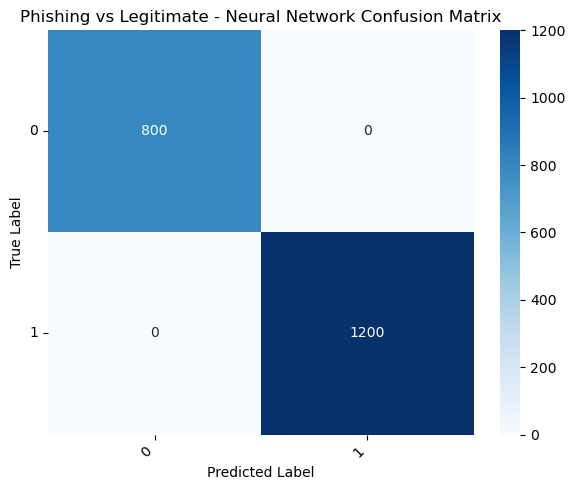

In [29]:
class_names = [0, 1]

plot_confusion_matrix(
    y_true=y_true_test,
    y_pred=y_pred_test,
    class_names=class_names,
    title="Phishing vs Legitimate - Neural Network Confusion Matrix",
    figsize=(6, 5),
)


In [30]:
def test_phishing_binary_examples(examples, vectorizer, model, device, threshold=0.5):
    """
    Similar to the classical phishing example tests, but for binary NN.
    """
    model.eval()
    for i, text in enumerate(examples, start=1):
        X_vec = vectorizer.transform([text])
        X_np = X_vec.toarray().astype(np.float32)
        X_tensor = torch.from_numpy(X_np).to(device)

        with torch.no_grad():
            logits = model(X_tensor)
            prob_phish = torch.sigmoid(logits).item()

        pred_label = 1 if prob_phish >= threshold else 0
        label_str = "Phishing" if pred_label == 1 else "Legitimate"

        print("=" * 80)
        print(f"Example {i}")
        print("-" * 80)
        print(text.strip()[:600])
        print("\nPrediction:")
        print(f"  Predicted label:      {label_str}")
        print(f"  Probability phishing: {prob_phish:.3f}")
        print(f"  Threshold:            {threshold:.2f}")
        print("=" * 80, "\n")


example_emails = [
    "Hi team, just a reminder that our meeting is scheduled for next Tuesday at 3 PM. Let me know if you need to reschedule.",
    "URGENT: Your bank account has been locked due to suspicious activity. Click the link below to verify your credentials and restore access immediately.",
    "We noticed a new sign-in to your email account from a Chrome browser on Windows. If this was not you, please secure your account here: http://security-check.example.com",
    "Congratulations! You've won a $500 gift card. To claim your prize, please fill out the attached form with your full name, address, and social security number.",
]

test_phishing_binary_examples(example_emails, vectorizer, model, device, threshold=THRESHOLD)


Example 1
--------------------------------------------------------------------------------
Hi team, just a reminder that our meeting is scheduled for next Tuesday at 3 PM. Let me know if you need to reschedule.

Prediction:
  Predicted label:      Legitimate
  Probability phishing: 0.014
  Threshold:            0.50

Example 2
--------------------------------------------------------------------------------
URGENT: Your bank account has been locked due to suspicious activity. Click the link below to verify your credentials and restore access immediately.

Prediction:
  Predicted label:      Phishing
  Probability phishing: 0.998
  Threshold:            0.50

Example 3
--------------------------------------------------------------------------------
We noticed a new sign-in to your email account from a Chrome browser on Windows. If this was not you, please secure your account here: http://security-check.example.com

Prediction:
  Predicted label:      Phishing
  Probability phishing: 0.88

In [31]:
num_samples = len(df)
num_train = len(X_train)
num_test = len(X_test)

num_phish_total = int(df["label"].sum())
num_legit_total = num_samples - num_phish_total

num_phish_test = int(y_true_test.sum())
num_legit_test = len(y_true_test) - num_phish_test

print("=== Neural Network Phishing Model Summary ===\n")
print(f"Total samples:              {num_samples}")
print(f"  Legitimate (0):           {num_legit_total}")
print(f"  Phishing (1):             {num_phish_total}")
print()
print(f"Train size:                 {num_train}")
print(f"Test size:                  {num_test}")
print()
print(f"Test set class counts:")
print(f"  Legitimate (0):           {num_legit_test}")
print(f"  Phishing (1):             {num_phish_test}")
print()
print("Performance on Test Set:")
print(f"  Accuracy:                 {final_metrics['accuracy']:.4f}")
print(f"  Precision:                {final_metrics['precision']:.4f}")
print(f"  Recall:                   {final_metrics['recall']:.4f}")
print(f"  F1-score:                 {final_metrics['f1']:.4f}")
print()
print("Model architecture:")
print(model)


=== Neural Network Phishing Model Summary ===

Total samples:              10000
  Legitimate (0):           4000
  Phishing (1):             6000

Train size:                 8000
Test size:                  2000

Test set class counts:
  Legitimate (0):           800
  Phishing (1):             1200

Performance on Test Set:
  Accuracy:                 1.0000
  Precision:                1.0000
  Recall:                   1.0000
  F1-score:                 1.0000

Model architecture:
FeedForwardNet(
  (neural_net): Sequential(
    (0): Linear(in_features=1497, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [32]:
import joblib

os.makedirs("../models", exist_ok=True)
os.makedirs("models", exist_ok=True)

# Save NN weights (for PyTorch)
PHISH_NN_MODEL_PATH = "models/nn_phish_model.pth"
torch.save(model.state_dict(), PHISH_NN_MODEL_PATH)
print(f"Saved phishing NN weights to {PHISH_NN_MODEL_PATH}")

# Save TF–IDF vectorizer (consistent with other models)
PHISH_NN_VECTORIZER_PATH = "../models/nn_phish_vectorizer.joblib"
joblib.dump(vectorizer, PHISH_NN_VECTORIZER_PATH)
print(f"Saved phishing NN vectorizer to {PHISH_NN_VECTORIZER_PATH}")


Saved phishing NN weights to models/nn_phish_model.pth
Saved phishing NN vectorizer to ../models/nn_phish_vectorizer.joblib
